<a href="https://colab.research.google.com/github/JosephMacula/math_and_AI_seminar/blob/main/llm_project/llm_proj_step2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!wget -q https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
import torch

with open('input.txt', 'r') as f:
    text = f.read()

vocab = sorted(set(text))
V = len(vocab)
stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for i, ch in enumerate(vocab)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join(itos[i] for i in ids)

ids = encode(text)

# Count matrix: same result as Step 1's loop, but vectorized
ids_t = torch.tensor(ids)
N = torch.bincount(ids_t[:-1] * V + ids_t[1:], minlength=V * V).view(V, V)

P = (N + 1).float()
P = P / P.sum(dim=1, keepdim=True)

def sample(P, n=500, start='\n'):
    cur, out = stoi[start], []
    for _ in range(n):
        cur = torch.multinomial(P[cur], num_samples=1).item()
        out.append(cur)
    return decode(out)

# Sanity checks against Step 1's checkpoints
assert len(text) == 1_115_394 and V == 65
assert N.sum().item() == len(text) - 1
assert (N == 0).sum().item() == 2822

In [4]:
import torch

X = torch.tensor([
    [ 0.0,  0.0],   # inside
    [ 0.5,  0.25],  # inside
    [ 1.0,  0.0],   # boundary
    [ 0.8,  0.5],   # outside
    [-0.4, -0.2],   # inside, negative coordinates
])
print(X.shape)      # (5, 2): five points, two features per point

torch.Size([5, 2])


In [5]:
h_units = torch.stack([
    torch.relu( X[:, 0]),
    torch.relu(-X[:, 0]),
    torch.relu( X[:, 1]),
    torch.relu(-X[:, 1]),
], dim=1)

print(h_units)
print(h_units.shape)                 # (5, 4)
r_units = h_units.sum(dim=1)
print(r_units)                       # |x1| + |x2| for each point

tensor([[0.0000, -0.0000, 0.0000, -0.0000],
        [0.5000, 0.0000, 0.2500, 0.0000],
        [1.0000, 0.0000, 0.0000, -0.0000],
        [0.8000, 0.0000, 0.5000, 0.0000],
        [0.0000, 0.4000, 0.0000, 0.2000]])
torch.Size([5, 4])
tensor([0.0000, 0.7500, 1.0000, 1.3000, 0.6000])


In [ ]:
# W1 = torch.tensor([
#     [ 1.0,  0.0],
#     [-1.0,  0.0],
#     [ 0.0,  1.0],
#     [ 0.0, -1.0],
# ])
# b1 = torch.zeros(4)

# a1 = X @ W1.T + b1
# h = torch.relu(a1)

# print(a1.shape, h.shape)             # both (5, 4)
# assert torch.allclose(h, h_units)

In [ ]:
# gamma = 4.0
# W2 = gamma * torch.tensor([
#     [ 1.0,  1.0,  1.0,  1.0],   # outside logit
#     [-1.0, -1.0, -1.0, -1.0],   # inside logit
# ])
# b2 = gamma * torch.tensor([-1.0, 1.0])

# logits = h @ W2.T + b2            # (5, 2)
# shifted = logits - logits.max(dim=1, keepdim=True).values
# weights = shifted.exp()
# probs = weights / weights.sum(dim=1, keepdim=True)

# print(logits)
# print(probs)
# print(probs.sum(dim=1))

In [6]:

def diamond_net(X, gamma = 0.4):
  W1 = torch.tensor([
    [ 1.0,  0.0],
    [-1.0,  0.0],
    [ 0.0,  1.0],
    [ 0.0, -1.0],
  ])
  b1 = torch.zeros(4)
  # b1 = torch.full((4,), 0.3)

  z1 = X @ W1.T + b1
  a1 = torch.relu(z1)
  print(a1)
  W2 = torch.tensor([
    [-1.0, -1.0, -1.0, -1.0]   # inside logit
  ])
  b2 = torch.tensor([1.0])
  z2 = a1 @ W2.T + b2
  a2 = z2

  return a2



In [6]:
diamond_net(torch.tensor([0.5,0.5]))

tensor([0.5000, 0.0000, 0.5000, 0.0000])


tensor([0.])

tensor([[0.0000, 1.6000, 0.0000, 1.6000],
        [0.0000, 1.5840, 0.0000, 1.6000],
        [0.0000, 1.5680, 0.0000, 1.6000],
        ...,
        [1.5680, 0.0000, 1.6000, 0.0000],
        [1.5840, 0.0000, 1.6000, 0.0000],
        [1.6000, 0.0000, 1.6000, 0.0000]])


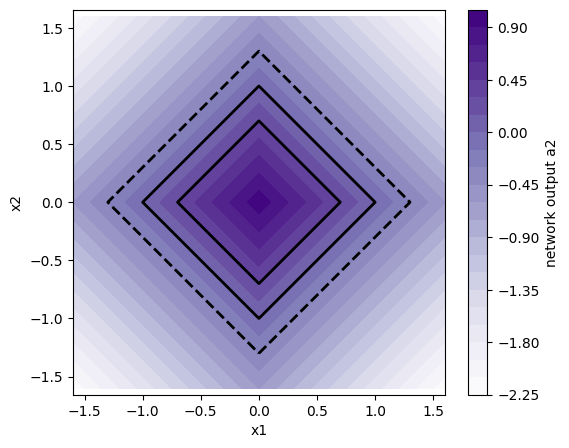

In [7]:
import matplotlib.pyplot as plt

axis = torch.linspace(-1.6, 1.6, 201)
gx, gy = torch.meshgrid(axis, axis, indexing='xy')
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1)

surface = diamond_net(grid).reshape(gx.shape)

plt.figure(figsize=(6, 5))
contour_plot = plt.contourf(gx.numpy(), gy.numpy(), surface.numpy(),
                            levels=30, cmap='Purples')
plt.contour(gx.numpy(), gy.numpy(), surface.numpy(),levels=[-0.3,0.0, 0.3]
            , colors='black', linewidths=2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')
plt.colorbar(contour_plot, label='network output a2')
plt.show()

In [8]:
xs = torch.tensor(ids[:-1])   # list slicing; current char, shape (n,)
ys = torch.tensor(ids[1:])    # next char,    shape (n,)
n = len(xs)                   # 1,115,393

In [9]:
def loss_fn(W):                                     # function definition (def)
    logits = W[xs]                                  # indexing by a tensor; (n, V): row a of W is z for input a
    logits = logits - logits.max(dim=1, keepdim=True).values   # stability: softmax is shift-invariant
    p = logits.exp()
    p = p / p.sum(dim=1, keepdim=True)              # (n, V) softmax rows
    return -p[torch.arange(n), ys].log().mean(), p  # method chaining; returns a tuple